In [2]:
# Import necessary libraries
import tensorflow as tf
import datetime
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import math
import os
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
checkpoint_filepath = '/content/drive/MyDrive/logs/best_model.keras'  # Path to save the best model

Mounted at /content/drive


In [3]:
df_timesteps = pd.read_pickle("/content/drive/MyDrive/all_timesteps.pkl")
df_timesteps.drop('source_folder',axis=1, inplace=True)

Y_Train = pd.get_dummies(df_timesteps.target.apply(pd.Series).stack()).groupby(level=0).sum()
df_timesteps = df_timesteps.join(Y_Train)
X_Train_cols = df_timesteps.columns[4:-4]
Y_Train_cols =df_timesteps.columns[-4:]
Extra_cols = df_timesteps.columns[0:4]
print(X_Train_cols,Y_Train_cols,Extra_cols)
print("features", len(X_Train_cols))



Index(['x0', 'y0', 'c0', 'x1', 'y1', 'c1', 'x2', 'y2', 'c2', 'x3', 'y3', 'c3',
       'x4', 'y4', 'c4', 'x5', 'y5', 'c5', 'x6', 'y6', 'c6', 'x7', 'y7', 'c7',
       'x8', 'y8', 'c8', 'x9', 'y9', 'c9', 'x10', 'y10', 'c10', 'x11', 'y11',
       'c11', 'x12', 'y12', 'c12', 'x13', 'y13', 'c13', 'x14', 'y14', 'c14',
       'x15', 'y15', 'c15', 'x16', 'y16', 'c16', 'x17', 'y17', 'c17', 'x18',
       'y18', 'c18', 'x19', 'y19', 'c19', 'x20', 'y20', 'c20', 'x21', 'y21',
       'c21', 'x22', 'y22', 'c22', 'x23', 'y23', 'c23', 'x24', 'y24', 'c24'],
      dtype='object') Index([0, 1, 2, 3], dtype='object') Index(['target', 'sequence', 'timestep', 'fps'], dtype='object')
features 75


In [4]:
df_timesteps.shape

(20908, 83)

In [5]:
import math
# Step 2: Preprocessing data (for sequence prediction) look_back dt: seconds
def create_dataset(df, look_back=4):
    X, y = [], []
    X_frames=[]
    classes = list(set(df.target))
    samples_count=0
    for i in classes:
      print("class", i)
      sequences = list(set(df[df.target == i]["sequence"]))
      #for each video
      for i2 in sequences:
        #print("sequence", i2)
        df_frames = df[ (df.target==i) & (df.sequence == i2) ].copy()
        fps = df_frames.iloc[10]["fps"].astype(int)
        target = df_frames.iloc[10][Y_Train_cols].to_numpy()
        #print("original",df_frames.shape[0])
        #to get homogenous fps
        if fps==30:
            #remove every 6th frame
            df_frames_filtered=df_frames[df_frames.index % 6 != 0].copy()
        if fps==24:
            #double every 24th frame
            df_frames_filtered=pd.concat([df_frames , df_frames[df_frames.index%24==0] ],ignore_index=True,axis=0)
            df_frames_filtered.sort_values(by="timestep",inplace=True)
        if fps ==25:
            df_frames_filtered=df_frames.copy()
        #print(fps)
        #print("filtered",df_frames_filtered.shape[0])

        #split video in 4s multiframe
        for i3 in range(math.floor(df_frames_filtered.shape[0]/25) - look_back):
            samples_count+=1
            #print("sample", samples_count)
            multiframe=(df_frames[i3*25:(i3 + look_back)*25][X_Train_cols]).to_numpy()
            multiframe = np.nan_to_num(multiframe, nan=0.0)
            # input shape -> [samples, window_size, n_features]
            #print(multiframe)
            X.append(multiframe)
            y.append(target)
    return np.array(X), np.array(y)

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
x_scaled = pd.DataFrame(data=scaler.fit_transform(df_timesteps[X_Train_cols]), columns=X_Train_cols)
df_scaled = pd.concat([df_timesteps[Extra_cols],x_scaled,df_timesteps[Y_Train_cols]] ,axis=1)

# Create dataset 4seconds * 24/25/30 fps -> 20 with 0-4 / 0-5 / 0-10 shifts
look_back = 4
X, y = create_dataset(df_scaled, look_back)
# Let's have a look at the training data
print(X.shape, y.shape)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3,shuffle=True, random_state=0)



class 0
class 1
class 2
class 3
(477, 100, 75) (477, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 75)             │        45,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,504 (287.12 KB)

 Trainable params: 73,504 (287.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - accuracy: 0.4840 - loss: 1.3298 - val_accuracy: 0.6597 - val_loss: 1.0652 - learning_rate: 0.0010
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6599 - loss: 0.9769 - val_accuracy: 0.5903 - val_loss: 1.0630 - learning_rate: 0.0010
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6673 - loss: 0.8797 - val_accuracy: 0.8472 - val_loss: 0.5305 - learning_rate: 0.0010
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8388 - loss: 0.5242 - val_accuracy: 0.8611 - val_loss: 0.4210 - learning_rate: 0.0010
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8585 - loss: 0.4103 - val_accuracy: 0.8681 - val_loss: 0.3587 - learning_rate: 0.0010
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9110 - loss: 0.3363 - val_accuracy: 0.8333 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8796 - loss: 0.3830 - val_accuracy: 0.9028

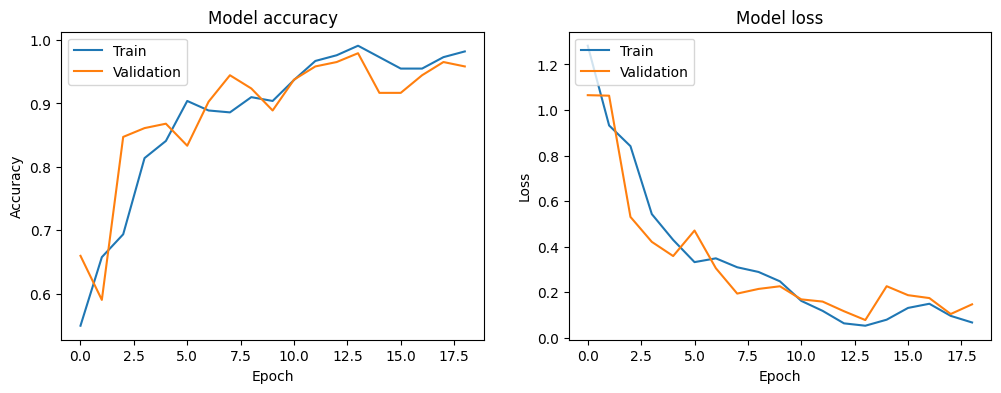

In [6]:
from keras.optimizers import Adam
def create_model(window_size,features):
  return tf.keras.models.Sequential([
    tf.keras.layers.LSTM(75, input_shape=(window_size, features, )),
    tf.keras.layers.Dense(100, activation='relu'), #hidden layer
    tf.keras.layers.Dense(100, activation='relu'), #hidden layer
    tf.keras.layers.Dense(100, activation='relu'), #hidden layer
    layers.Dense(4, activation='softmax')
])
optimizer = Adam(learning_rate=0.001)
model = create_model(X.shape[1],X.shape[2])
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
#Callbacks

# 1. EarlyStopping: Stop training if the validation loss doesn't improve for 5 epochs
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 2. ModelCheckpoint: Save the best model during training

model_checkpoint_callback = ModelCheckpoint(filepath=checkpoint_filepath,
                                  monitor='val_loss',
                                  save_best_only=True)

# 3. ReduceLROnPlateau: Reduce the learning rate by a factor of 0.5 if validation loss doesn't improve for 3 epochs
reduce_lr_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=0.00001)

# 4. TensorBoard: Visualize training metrics with TensorBoard
# log_dir = './logs'  # Directory to save TensorBoard logs
# tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=1)
logdir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
# print(logdir)
tensorboard_callback = TensorBoard(logdir, histogram_freq=1)

# Combine all the callbacks
callbacks = [early_stopping_callback,model_checkpoint_callback, reduce_lr_callback, tensorboard_callback]

# Train the model with the callbacks
history = model.fit(x=X_train,
                    y=y_train,
                    epochs=60,
                    batch_size=40,
                    validation_data=(X_val, y_val),
                    callbacks=callbacks)

test_loss, test_acc = model.evaluate(X_val, y_val, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")


# Step 8: Plot Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
# ── Bestes Modell laden ───────────────────────────────────────────────────────
best_model = tf.keras.models.load_model(checkpoint_filepath)

# ── Predictions auf dem Test-Set sammeln ─────────────────────────────────────
all_preds, all_labels = [], []

y_prediction = model.predict(X)
y_prediction = np.argmax (y_prediction, axis = 1)
y_test=np.argmax(y, axis=1)
#Create confusion matrix and normalizes it over predicted (columns)
result = confusion_matrix(y_test, y_prediction , normalize='pred')
print(result)
class_names=["bicep curl","pull up","rope jump","Sit up"]

print(y_prediction.shape)

all_preds  = np.array(y_prediction)
all_labels = np.array(y_test)

present = list(np.unique(y_test))
present_names = [class_names[i] for i in present]

print(classification_report(
    all_labels, y_prediction,
    labels=present,
    target_names=present_names
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[0.99367089 0.00806452 0.         0.        ]
 [0.         0.98387097 0.00840336 0.01315789]
 [0.00632911 0.00806452 0.99159664 0.01315789]
 [0.         0.         0.         0.97368421]]
(477,)
              precision    recall  f1-score   support

  bicep curl       0.99      0.99      0.99       158
     pull up       0.98      0.98      0.98       124
   rope jump       0.99      0.98      0.98       121
      Sit up       0.97      1.00      0.99        74

    accuracy                           0.99       477
   macro avg       0.99      0.99      0.99       477
weighted avg       0.99      0.99      0.99       477



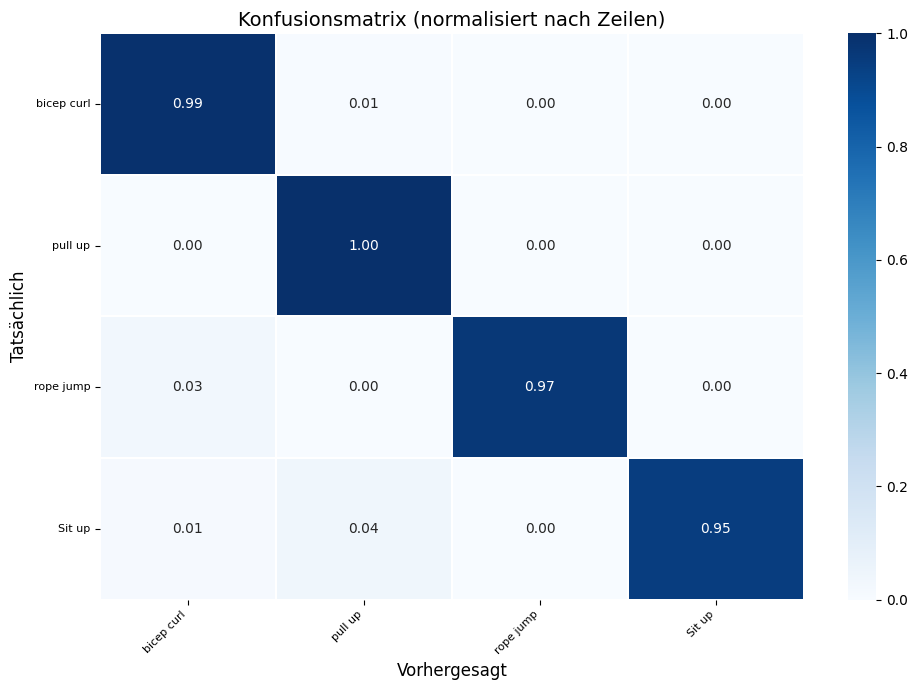

In [ ]:
# ── Konfusionsmatrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, labels=present, normalize='true')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=present_names, yticklabels=present_names,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Vorhergesagt', fontsize=12)
ax.set_ylabel('Tatsächlich',  fontsize=12)
ax.set_title('Konfusionsmatrix (normalisiert nach Zeilen)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()

# Tuned Model

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
#!pip install keras_tuner
import keras_tuner as kt


# Build the model
def build_model(hp):
    model = models.Sequential()

    # Convolutional Layers (Tunable number of LSTM layers and filters)
    for i in range(hp.Int('num_lstm_layers', 0, 3)):
      model.add(layers.LSTM(
            units=hp.Int(f'lstm_units_{i}', min_value=32, max_value=128, step=12),
            #units=75,
            input_shape=(X.shape[1], X.shape[2],),
            activation=hp.Choice(f'lstm_activation_{i}', values=['hard_tanh', 'tanh']),
            recurrent_activation=hp.Choice(f'recurrent_activation_{i}', values=['sigmoid', 'softsign']),
            dropout =hp.Float(f'lstm_dropout_rate_{i}', min_value=0.0, max_value=0.5, step=0.1),
            return_sequences=True
        ))
    model.add(layers.LSTM(
            units=hp.Int(f'lstm_units_final', min_value=32, max_value=128, step=12),
            input_shape=(X.shape[1], X.shape[2],),
            activation=hp.Choice(f'lstm_activation_final', values=['hard_tanh', 'tanh']),
            recurrent_activation=hp.Choice(f'recurrent_activation_final', values=['sigmoid', 'softsign']),
            dropout =hp.Float(f'lstm_dropout_rate_final', min_value=0.0, max_value=0.5, step=0.1)
        ))
    #tf.keras.layers.LSTM(75, input_shape=(window_size, features, )),

    # Dense Layers (Tunable number of Dense layers and neurons)
    for i in range(hp.Int('num_dense_layers', 1, 4)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=12),
            activation=hp.Choice(f'dense_activation_{i}', values=['relu', 'tanh'])
        ))
        model.add(layers.Dropout(rate=hp.Float(f'dropout_rate{i}', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(layers.Dense(4, activation='softmax'))


    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Instantiate the tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    #This means that after each round, only one-third of the
    #models will continue, and the resource allocation (epochs) will be multiplied by 3 for the next round.
    directory='hyperparam_tuning',
    project_name='fit_hyperparam_tuning'
)

# Run the hyperparameter search
tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=40)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 90 Complete [00h 00m 48s]
val_accuracy: 0.9861111044883728

Best val_accuracy So Far: 0.9930555820465088
Total elapsed time: 00h 48m 29s


In [25]:

# Print the best hyperparameters
print(f"Best number of additional lstm layers: {best_hps.get('num_lstm_layers')}")
for i in range(best_hps.get('num_lstm_layers')):
    print(f"Best number of lstm_units_ in lstm layer {i}: {best_hps.get(f'lstm_units_{i}')}")
    print(f"Best activation function {i}: {best_hps.get(f'lstm_activation_{i}')}")
    print(f"Best recurrent activation {i}: {best_hps.get(f'recurrent_activation_{i}')}")
    print(f"Best drop out rate lstm {i}: {best_hps.get(f'lstm_dropout_rate_{i}')}")

print(f"Best number of lstm_units_ in final layer {i}: {best_hps.get(f'lstm_units_final')}")
print(f"Best activation function final: {best_hps.get(f'lstm_activation_final')}")
print(f"Best recurrent activation final: {best_hps.get(f'recurrent_activation_final')}")
print(f"Best drop out rate lstm final: {best_hps.get(f'lstm_dropout_rate_final')}")

print(f"Best number of dense layers: {best_hps.get('num_dense_layers')}")
for i in range(best_hps.get('num_dense_layers')):
    print(f"Best number of units in dense layer {i}: {best_hps.get(f'units_{i}')}")
    print(f"Best dense activation function {i}: {best_hps.get(f'dense_activation_{i}')}")
    print(f"Best drop out rate {i}: {best_hps.get(f'dropout_rate{i}')}")

print(f"Best learning rate: {best_hps.get('learning_rate')}")

# Build the best model and train it
best_model = tuner.hypermodel.build(best_hps)


# Trial 90 Complete [00h 00m 48s]
# val_accuracy: 0.9861111044883728

# Best val_accuracy So Far: 0.9930555820465088
# Total elapsed time: 00h 48m 29s
# Best number of additional lstm layers: 1
# Best number of lstm_units_ in lstm layer 0: 116
# Best activation function 0: tanh
# Best recurrent activation 0: sigmoid
# Best drop out rate lstm 0: 0.0
# Best number of lstm_units_ in final layer 0: 92
# Best activation function final: hard_tanh
# Best recurrent activation final: softsign
# Best drop out rate lstm final: 0.1
# Best number of dense layers: 1
# Best number of units in dense layer 0: 92
# Best dense activation function 0: tanh
# Best drop out rate 0: 0.1
# Best learning rate: 0.0003742962516403957

Best number of additional lstm layers: 1
Best number of lstm_units_ in lstm layer 0: 116
Best activation function 0: tanh
Best recurrent activation 0: sigmoid
Best drop out rate lstm 0: 0.0
Best number of lstm_units_ in final layer 0: 92
Best activation function final: hard_tanh
Best recurrent activation final: softsign
Best drop out rate lstm final: 0.1
Best number of dense layers: 1
Best number of units in dense layer 0: 92
Best dense activation function 0: tanh
Best drop out rate 0: 0.1
Best learning rate: 0.0003742962516403957


Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9910 - loss: 0.0306 - val_accuracy: 0.9792 - val_loss: 0.0682 - learning_rate: 3.0000e-04
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9896 - loss: 0.0362 - val_accuracy: 0.9792 - val_loss: 0.0714 - learning_rate: 3.0000e-04
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9951 - loss: 0.0256 - val_accuracy: 0.9792 - val_loss: 0.0628 - learning_rate: 3.0000e-04
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9877 - loss: 0.0331 - val_accuracy: 0.9792 - val_loss: 0.0580 - learning_rate: 3.0000e-04
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9975 - loss: 0.0159 - val_accuracy: 0.9792 - val_loss: 0.0543 - learning_rate: 3.0000e-04
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9951 - loss: 0.0230 - val_accuracy: 0.9792 - val_loss: 0.0530 - learning_rate: 3.0000e-04
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9950 - loss: 0.0181

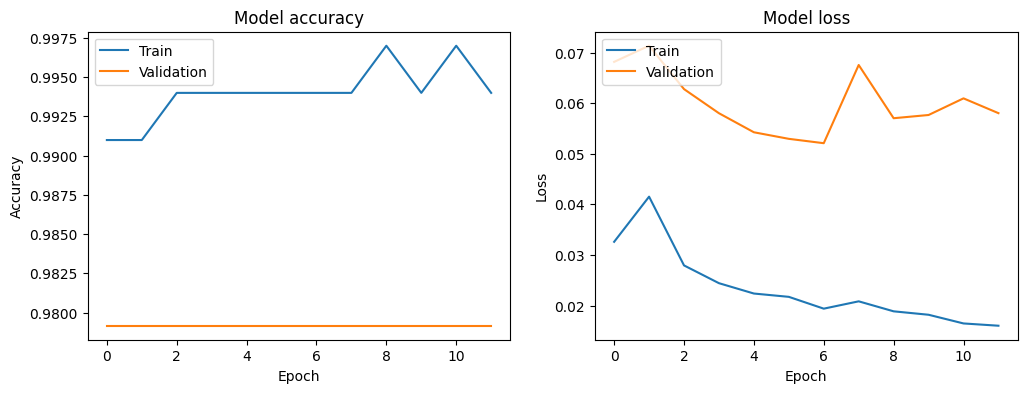

In [21]:

# Train the model with the callbacks
history = best_model.fit(x=X_train,
                    y=y_train,
                    epochs=60,
                    batch_size=40,
                    validation_data=(X_val, y_val),
                    callbacks=callbacks)

test_loss, test_acc = best_model.evaluate(X_val, y_val, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")


# Step 8: Plot Training and Validation Accuracy/Loss
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()